<a href="https://colab.research.google.com/github/BrunoZess/Fundamentos-de-IA/blob/main/Projeto_Final_Sentimentos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Sentimento de Avaliações de E-commerce (B2W)

**Integrantes:** Bruno Ulisses, Thiago, Paulo Vinicius

**Fonte dos dados:** Dataset B2W de avaliações de e-commerce brasileiro
(https://www.kaggle.com/datasets/fredericods/ptbr-sentiment-analysis-datasets)

**Objetivo:** Classificar automaticamente avaliações de clientes de
e-commerce como positivas ou negativas, com base apenas no texto da
avaliação (`review_text`). Uma aplicação assim pode ser usada, por
exemplo, para priorizar o atendimento a clientes insatisfeitos ou
monitorar a reputação de produtos em tempo real.

**Atributo-alvo:** `polarity` — variável categórica binária
(0 = avaliação negativa, 1 = avaliação positiva).

**Atributos preditivos:** `review_text` (texto livre da avaliação).

**Tipo da tarefa:** Classificação binária. O atributo-alvo representa
duas categorias (positivo/negativo), e não um valor numérico contínuo,
portanto a tarefa não é de regressão.

In [ ]:
# Instalação das bibliotecas necessárias (executar uma única vez)
!pip install -q wordcloud unidecode kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 7.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string
import unidecode

from wordcloud import WordCloud

plt.style.use('default')
sns.set_palette("husl")

## Carregamento dos dados

> **Nota sobre a fonte dos dados:** o carregamento abaixo usa
> `kagglehub`, que baixa o dataset diretamente do Kaggle sem precisar
> de nenhum arquivo local. Caso a gente queria hospedar o CSV no
> próprio repositório do GitHub (mais simples de garantir que roda
> sem autenticação), so substituir esta célula por:
>
> ```python
> dataset = pd.read_csv("https://raw.githubusercontent.com/<usuario>/<repo>/main/data/b2w.csv")
> ```

In [ ]:
import kagglehub

path = kagglehub.dataset_download('fredericods/ptbr-sentiment-analysis-datasets')
dataset = pd.read_csv(path + "/b2w.csv")

print(f"{dataset.shape[0]} linhas x {dataset.shape[1]} colunas")
dataset.head()

100%|██████████| 877M/877M [00:51<00:00, 17.8MB/s]

Extracting files...


132373 linhas x 8 colunas


,original_index,review_text,review_text_processed,review_text_tokenized,polarity,rating,kfold_polarity,kfold_rating
0,11955,Bem macio e felpudo...recomendo. Preço imbatí...,bem macio e felpudo...recomendo. preco imbati...,"['bem', 'macio', 'felpudo', 'recomendo', 'prec...",1.0,4,1,1
1,35478,Produto excepcional! recomendo!!! inovador e ...,produto excepcional! recomendo!!! inovador e ...,"['produto', 'excepcional', 'recomendo', 'inova...",1.0,5,1,1
2,122760,recebi o produto antes do prazo mas veio com d...,recebi o produto antes do prazo mas veio com d...,"['recebi', 'produto', 'antes', 'do', 'prazo', ...",0.0,1,1,1
3,17114,Bom custo beneficio. Adequado para pessoas que...,bom custo beneficio. adequado para pessoas que...,"['bom', 'custo', 'beneficio', 'adequado', 'par...",1.0,5,1,1
4,19112,Além de higiênico tem o tamanho ideal. Só falt...,alem de higienico tem o tamanho ideal. so falt...,"['alem', 'de', 'higienico', 'tem', 'tamanho', ...",NaN,3,-1,1


## 5.2 Compreensão dos dados

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132373 entries, 0 to 132372
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   original_index         132373 non-null  int64  
 1   review_text            132373 non-null  object 
 2   review_text_processed  132373 non-null  object 
 3   review_text_tokenized  132373 non-null  object 
 4   polarity               116058 non-null  float64
 5   rating                 132373 non-null  int64  
 6   kfold_polarity         132373 non-null  int64  
 7   kfold_rating           132373 non-null  int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 8.1+ MB


O dataset possui 132.373 linhas e 8 colunas. Além das colunas originais (review_text, rating, polarity), o arquivo já vem com versões pré-processadas do texto (review_text_processed, review_text_tokenized) e colunas de particionamento para validação cruzada (kfold_polarity, kfold_rating). Não tem colunas com tipo inadequado, review_text é object (string), rating é int64, e polarity é float64 (por conter valores ausentes, o pandas não permite tipo inteiro puro).

In [ ]:
null_texts = dataset.query("review_text.isna()")
null_polarity = dataset.query("polarity.isna()")

print(f"{len(null_texts)} textos nulos")
print(f"{len(null_polarity)} polaridades nulas")
print(f"{dataset.duplicated().sum()} linhas duplicadas")

0 textos nulos
16315 polaridades nulas
0 linhas duplicadas


Não há textos nulos nem linhas duplicadas no dataset. Porém, existem 16.315 valores ausentes na coluna polarity, ou seja, aproximadamente 12,3% das avaliações não possuem rótulo de sentimento definido.

In [ ]:
if len(dataset.query("polarity.isna()")) > 0:
    ratings_without_polarity = dataset.query("polarity.isna()")["rating"].unique()
    print(f"Ratings das avaliações sem polaridade: {sorted(ratings_without_polarity)}")
    for rating in sorted(ratings_without_polarity):
        count = len(dataset.query("polarity.isna() and rating == @rating"))
        print(f"Rating {rating}: {count:,} avaliações")

Ratings das avaliações sem polaridade: [np.int64(3)]
Rating 3: 16,315 avaliações


Todas as 16.315 avaliações sem polaridade correspondem exclusivamente a avaliações com rating = 3. Isso confirma a hipótese: nota 3 representa uma experiência "neutra" ou ambígua, sem consenso claro entre positivo e negativo, e por isso o próprio dataset decidiu não atribuir polaridade a essas notas. Por não haver critério para rotular esses casos, mantemos a decisão de removê-los da análise.

In [ ]:
all_polarities = dataset["polarity"].unique()

print("Distribuição do atributo-alvo:")
for pol in sorted([p for p in all_polarities if pd.notna(p)]):
    count = len(dataset.query("polarity == @pol"))
    percentage = (count / len(dataset)) * 100
    print(f"Polaridade {pol}: {count:,} avaliações ({percentage:.1f}%)")

nan_sum = dataset["polarity"].isna().sum()
if nan_sum > 0:
    percentage = (nan_sum / len(dataset)) * 100
    print(f"NaN: {nan_sum:,} avaliações ({percentage:.1f}%)")

Distribuição do atributo-alvo:
Polaridade 0.0: 35,758 avaliações (27.0%)
Polaridade 1.0: 80,300 avaliações (60.7%)
NaN: 16,315 avaliações (12.3%)


Das avaliações com polaridade definida, 80.300 (60,7%) são positivas e 35.758 (27,0%) são negativas, uma proporção de aproximadamente 2,25 avaliações positivas para cada negativa. Isso confirma o desbalanceamento de classes esperado em reviews de e-commerce, e reforça a necessidade do balanceamento por undersampling aplicado na seção 5.4, evitando que o modelo aprenda simplesmente a "sempre prever positivo" para maximizar a acurácia bruta.

## 5.3 Análise exploratória

Nesta seção exploramos o conteúdo textual das avaliações antes de
qualquer tratamento, para entender que tipo de vocabulário domina
cada classe.

In [ ]:
def wordcloud(dataframe: pd.DataFrame, text_column: str, title: str = "Nuvem de Palavras"):
    every_word = ' '.join([text for text in dataframe[text_column]])

    word_cloud = WordCloud(
        width=800,
        height=500,
        max_font_size=80,
        background_color='black',
        colormap='viridis'
    ).generate(every_word)

    plt.figure(figsize=(12, 8))
    plt.imshow(word_cloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

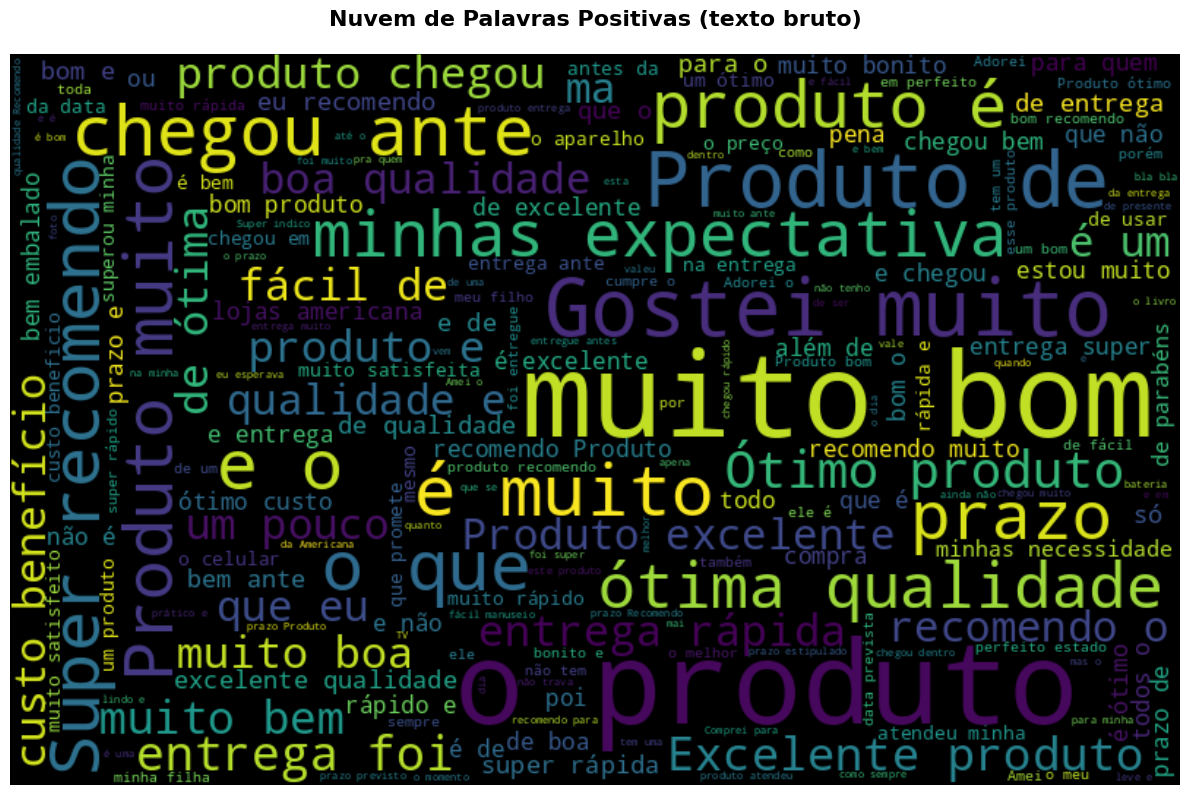

In [ ]:
all_pos = dataset.query("polarity == 1.0")
wordcloud(all_pos, "review_text", "Nuvem de Palavras Positivas (texto bruto)")

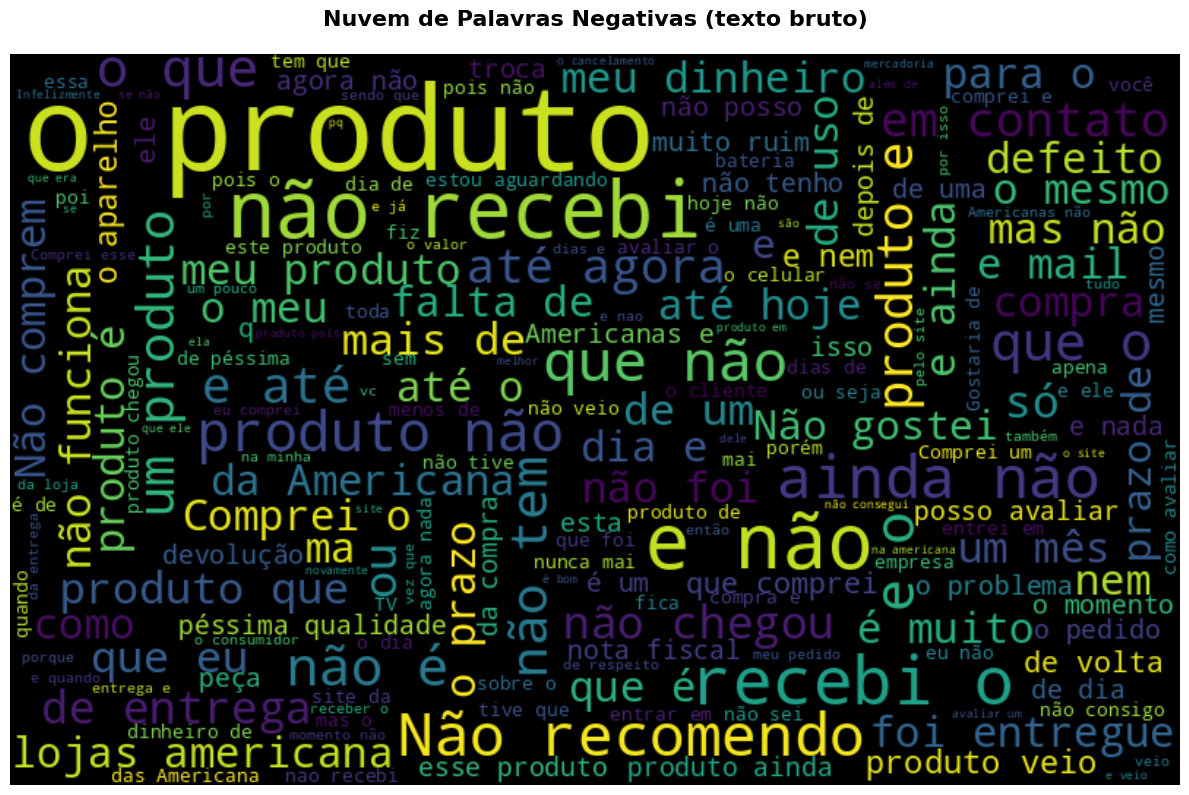

In [ ]:
all_neg = dataset.query("polarity == 0.0")
wordcloud(all_neg, "review_text", "Nuvem de Palavras Negativas (texto bruto)")

Sem nenhum tratamento, as nuvens de palavras tendem a ser
dominadas por *stopwords* (artigos, preposições, pronomes) e não
revelam ainda diferenças claras entre as classes, isso motiva o
pré-processamento textual feito na seção 5.4.

In [ ]:
dataset["text_length"] = dataset["review_text"].str.len()
dataset.groupby("polarity")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
polarity,,,,,,,,
0.0,35758.0,199.350076,180.882066,50.0,89.0,144.0,244.0,3924.0
1.0,80300.0,116.143786,103.071184,50.0,64.0,85.0,127.0,4548.0


Avaliações negativas (polaridade 0) têm em média 199 caracteres, quase o dobro da média de 116 caracteres das avaliações positivas. A mediana segue o mesmo padrão (144 vs. 85 caracteres), e o desvio-padrão das negativas também é maior (180,9 vs. 103,1), indicando textos mais variados em tamanho. Isso confirma a hipótese: clientes insatisfeitos tendem a escrever avaliações mais longas, provavelmente para detalhar o problema, enquanto avaliações positivas costumam ser mais curtas e diretas (ex: "ótimo produto, recomendo"). Ambas as distribuições são fortemente assimétricas à direita (a maioria dos textos é curta, com poucos casos bem longos, chegando a ~4.000 caracteres).

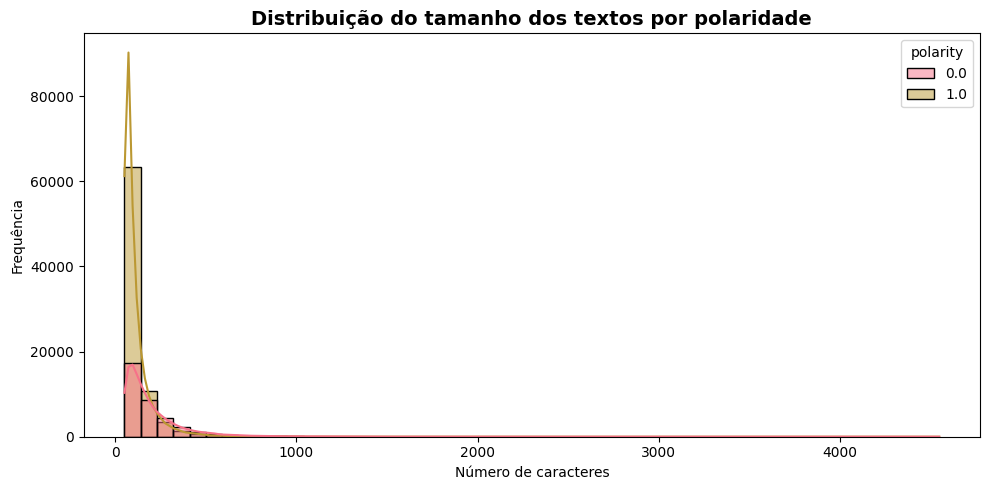

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(data=dataset, x="text_length", hue="polarity", bins=50, kde=True)
plt.title("Distribuição do tamanho dos textos por polaridade", fontsize=14, fontweight='bold')
plt.xlabel("Número de caracteres")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

In [ ]:
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

def tokenizer(dataframe, text_column, lower=True):
    tk = nltk.tokenize.WordPunctTokenizer()

    if lower:
        every_word = ' '.join([text.lower() for text in dataframe[text_column]])
    else:
        every_word = ' '.join([text for text in dataframe[text_column]])

    tokens = tk.tokenize(every_word)
    print(f"Token count: {len(tokens):,}")
    print(f"Unique tokens: {len(set(tokens)):,}")
    return tokens


def word_frequencies_graphic(tokenized_data, n_largest, title="Frequência de tokens"):
    frequency = nltk.FreqDist(tokenized_data)

    frequency_df = pd.DataFrame({
        "word": list(frequency.keys()),
        "frequency": list(frequency.values())
    })

    top_words = frequency_df.nlargest(columns="frequency", n=n_largest)

    plt.figure(figsize=(14, 8))
    ax = sns.barplot(data=top_words, x="word", y="frequency", palette="viridis")
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.xlabel("Palavras", fontsize=12)
    plt.ylabel("Frequência", fontsize=12)
    plt.xticks(rotation=45, ha='right')

    for i, v in enumerate(top_words['frequency']):
        ax.text(i, v + 0.5, str(v), ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()
    return top_words

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Token count: 3,665,440
Unique tokens: 73,271


/tmp/ipykernel_3127/3979448827.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_words, x="word", y="frequency", palette="viridis")


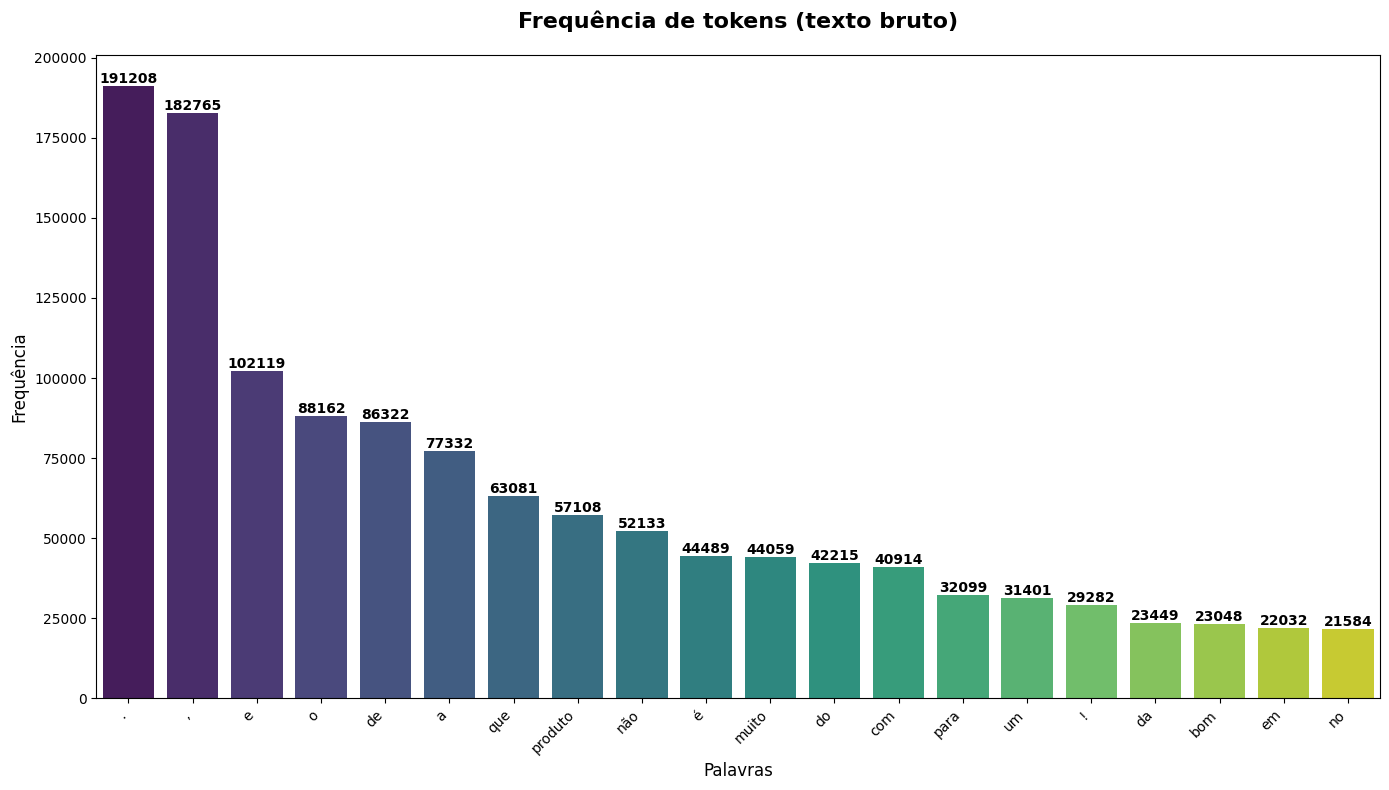

In [ ]:
tokens = tokenizer(dataset, "review_text", lower=False)
top_words = word_frequencies_graphic(tokens, 20, "Frequência de tokens (texto bruto)")

Como esperado antes de qualquer tratamento, as palavras mais frequentes são majoritariamente pontuação (., ,, !) e palavras de parada do português (e, o, de, a, que, não, é, do, com, para, um, da, em, no). A única palavra de conteúdo relevante que aparece no top 20 é "produto" (57.108 ocorrências) e "muito" (44.059) e "bom" (23.048), ou seja, mesmo sem tratamento, já há um leve lado positivo aparente. Esse resultado reforça a necessidade da remoção de stopwords e pontuação (seção 5.4): sem esse tratamento, qualquer análise de vocabulário fica dominada por termos sem significado, mascarando os padrões que de fato diferenciam avaliações positivas de negativas.

## 5.4 Pré-processamento

Cada tratamento aplicado abaixo é justificado individualmente,
seguindo o problema identificado, o tratamento escolhido e o motivo
da escolha.

**Problema 1 — valores ausentes.**
Textos e polaridades nulos não podem ser usados para treinar ou
avaliar um classificador de texto.
**Tratamento:** remoção das linhas com `review_text` ou `polarity`
ausentes.

**Problema 2 — textos vazios (strings em branco).**
Algumas linhas têm `review_text` como string vazia após strip, o que
não carrega nenhuma informação textual.
**Tratamento:** remoção dessas linhas.

In [ ]:
af = len(dataset)
dataset.dropna(subset=["review_text", "polarity"], inplace=True)
bf = len(dataset)
print(f"Linhas removidas por valores nulos: {af - bf:,}")

bf = len(dataset)
dataset = dataset[dataset["review_text"].str.strip().astype(bool)]
af = len(dataset)
print(f"Linhas removidas por texto vazio: {bf - af:,}")

Linhas removidas por valores nulos: 16,315
Linhas removidas por texto vazio: 0


Foram removidas 16.315 linhas por valores nulos (correspondendo exatamente às avaliações de rating 3 sem polaridade, identificadas na seção 5.2). Não houve remoção adicional por texto vazio, indicando que todas as avaliações com review_text preenchido continham conteúdo textual real após o strip.

**Problema 3 — desbalanceamento de classes.**
Como visto na seção 5.2, há muito mais avaliações positivas que
negativas. Treinar um modelo nesses dados sem correção tende a
produzir um classificador enviesado, que aprende a prever a classe
majoritária na maioria dos casos.
**Tratamento:** undersampling da classe majoritária (positiva), para
igualar o número de exemplos por classe.
**Justificativa:** o dataset é grande o suficiente para que reduzir a
classe majoritária ainda deixe exemplos suficientes para o
treinamento, e essa abordagem é mais simples e transparente do que
técnicas de oversampling sintético (como SMOTE) para dados textuais.

In [ ]:
positives = dataset.query("polarity == 1.0").shape[0]
negatives = dataset.query("polarity == 0.0").shape[0]
total = positives + negatives

print(f"% Positivos: {positives/total*100:.1f}% ({positives:,})")
print(f"% Negativos: {negatives/total*100:.1f}% ({negatives:,})")

n_neg = negatives
pos_sample = dataset.query("polarity == 1.0").sample(n=n_neg, random_state=42)
neg_sample = dataset.query("polarity == 0.0")

dataset = pd.concat([pos_sample, neg_sample], ignore_index=True)

print(f"\nApós balanceamento -> Total: {len(dataset):,}")
print(f"Negativos: {len(dataset.query('polarity == 0.0')):,}")
print(f"Positivos: {len(dataset.query('polarity == 1.0')):,}")

% Positivos: 69.2% (80,300)
% Negativos: 30.8% (35,758)

Após balanceamento -> Total: 71,516
Negativos: 35,758
Positivos: 35,758


Antes do balanceamento, o dataset tinha 69,2% de avaliações positivas (80.300) contra 30,8% de negativas (35.758) — uma razão de aproximadamente 2,25:1. Após o undersampling da classe majoritária, o dataset ficou perfeitamente balanceado, com 35.758 exemplos de cada classe (total de 71.516 avaliações), eliminando o viés de classe para a etapa de modelagem.

**Problema 4 — variação textual (maiúsculas/minúsculas, acentos,
pontuação, stopwords).**
Palavras como "Bom", "bom" e "BOM" são semanticamente idênticas, mas
seriam tratadas como tokens diferentes sem normalização. O mesmo vale
para acentuação ("não" vs "nao"). Pontuação e stopwords (artigos,
preposições) não carregam carga semântica relevante para a tarefa.
**Tratamento:** conversão para minúsculas, remoção de acentos
(unidecode), remoção de pontuação e de stopwords em português.

In [ ]:
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

puncts = [p for p in string.punctuation]
stopwords = list(set([
    unidecode.unidecode(stopword)
    for stopword in nltk.corpus.stopwords.words("portuguese")
]))
stopwords_puncts = sorted(stopwords + puncts)
print(f"Stop words: {len(stopwords)}")

word_punct_tokenizer = nltk.tokenize.WordPunctTokenizer()

def process_text(tokens):
    processed_words = []
    for word in tokens:
        processed_word = unidecode.unidecode(word.lower())
        if processed_word not in stopwords_puncts and processed_word.strip():
            processed_words.append(processed_word)
    return " ".join(processed_words)

def process_column(dataframe, text_column, output_column="treated_text"):
    treated_texts = []
    total_texts = len(dataframe)

    for i, review in enumerate(dataframe[text_column]):
        if i % 2000 == 0:
            print(f"   Processando: {i+1:,}/{total_texts:,} ({((i+1)/total_texts)*100:.1f}%)")
        tokens = word_punct_tokenizer.tokenize(review)
        treated_texts.append(process_text(tokens))

    dataframe[output_column] = treated_texts

process_column(dataset, "review_text")
print("Tratamento de texto concluído! ✅")

Stop words: 200
   Processando: 1/71,516 (0.0%)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


   Processando: 2,001/71,516 (2.8%)
   Processando: 4,001/71,516 (5.6%)
   Processando: 6,001/71,516 (8.4%)
   Processando: 8,001/71,516 (11.2%)
   Processando: 10,001/71,516 (14.0%)
   Processando: 12,001/71,516 (16.8%)
   Processando: 14,001/71,516 (19.6%)
   Processando: 16,001/71,516 (22.4%)
   Processando: 18,001/71,516 (25.2%)
   Processando: 20,001/71,516 (28.0%)
   Processando: 22,001/71,516 (30.8%)
   Processando: 24,001/71,516 (33.6%)
   Processando: 26,001/71,516 (36.4%)
   Processando: 28,001/71,516 (39.2%)
   Processando: 30,001/71,516 (42.0%)
   Processando: 32,001/71,516 (44.7%)
   Processando: 34,001/71,516 (47.5%)
   Processando: 36,001/71,516 (50.3%)
   Processando: 38,001/71,516 (53.1%)
   Processando: 40,001/71,516 (55.9%)
   Processando: 42,001/71,516 (58.7%)
   Processando: 44,001/71,516 (61.5%)
   Processando: 46,001/71,516 (64.3%)
   Processando: 48,001/71,516 (67.1%)
   Processando: 50,001/71,516 (69.9%)
   Processando: 52,001/71,516 (72.7%)
   Processando: 54,

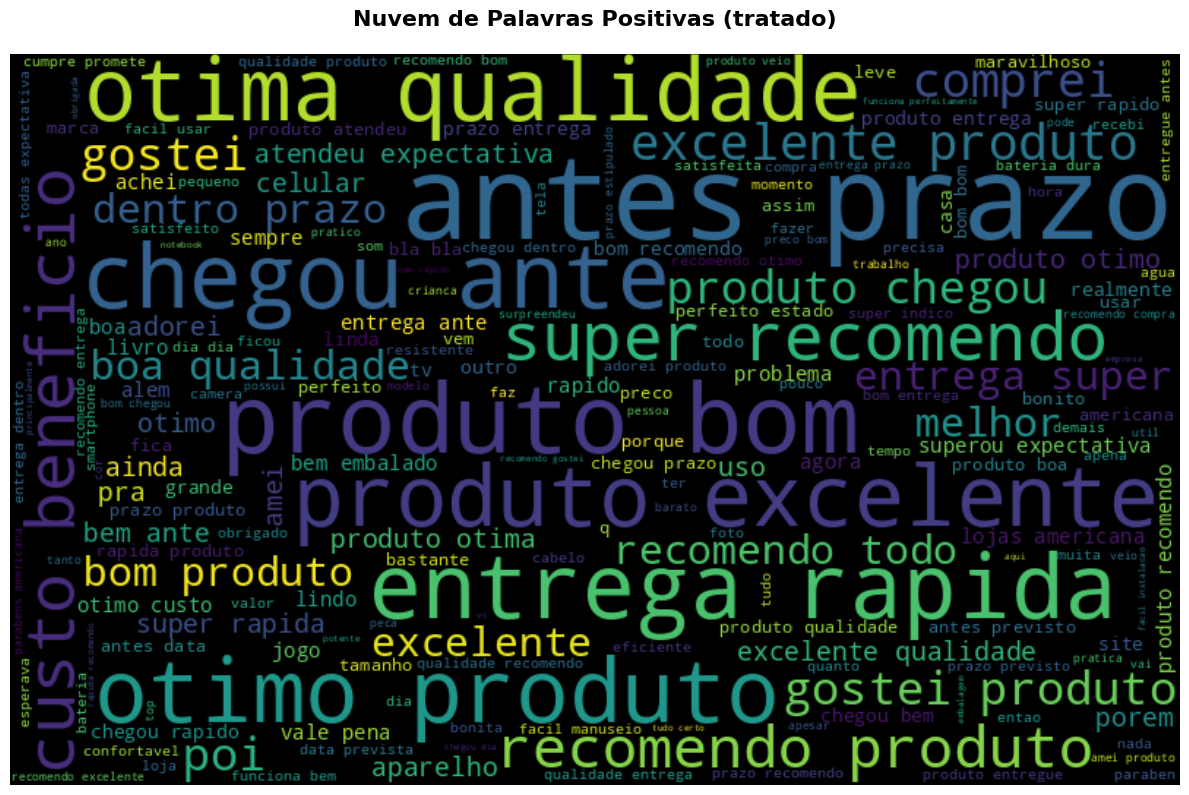

In [ ]:
wordcloud(dataset.query("polarity == 1.0"), "treated_text", "Nuvem de Palavras Positivas (tratado)")

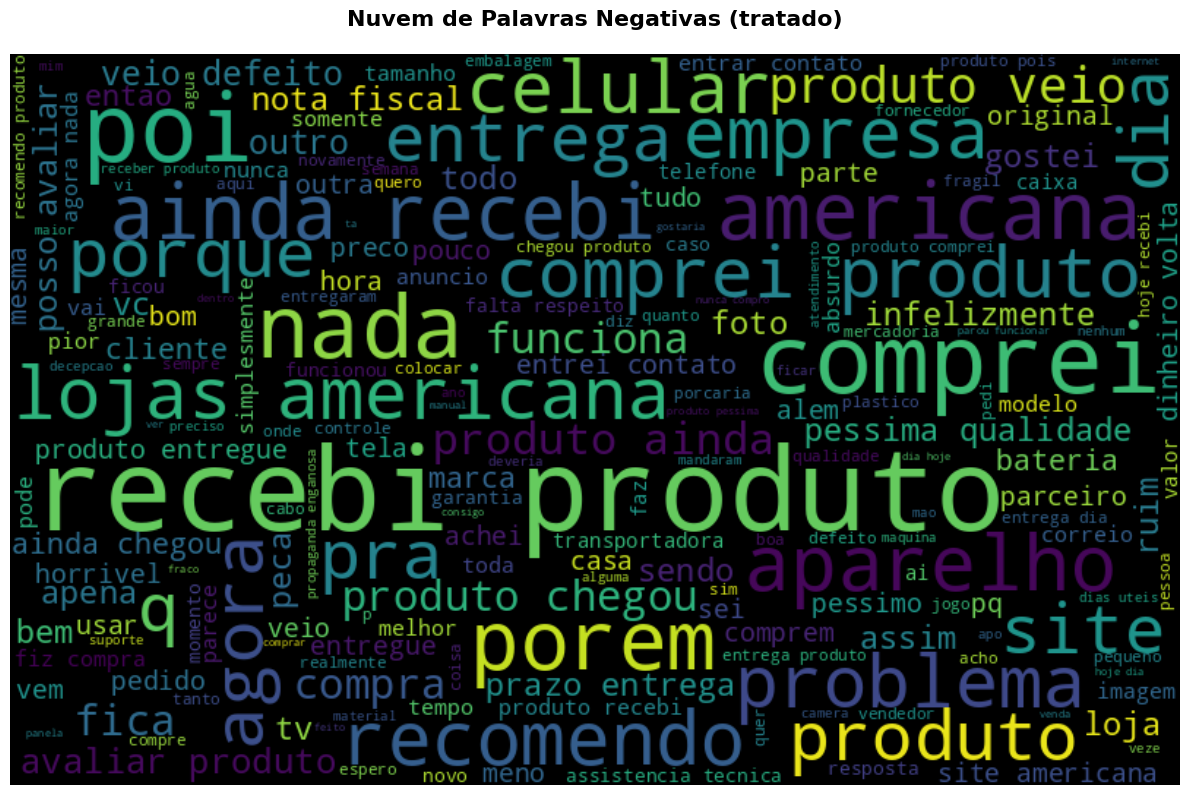

In [ ]:
wordcloud(dataset.query("polarity == 0.0"), "treated_text", "Nuvem de Palavras Negativas (tratado)")

Após a remoção de stopwords, pontuação e normalização, as nuvens de palavras revelam padrões claramente distintos entre as classes. Na nuvem positiva, destacam-se termos como "ótima", "qualidade", "recomendo", "excelente", "chegou", "entrega rápida", "gostei", "custo benefício" e "superou expectativa" — vocabulário associado à satisfação com o produto e com a entrega. Já na nuvem negativa, predominam termos como "recebi", "produto", "porém", "problema", "nada", "não funciona", "pior", "defeito", "péssima", "horrível", "infelizmente" e "não recomendo" — vocabulário ligado a defeitos do produto e frustração com a experiência. Essa diferença de vocabulário confirma que o pré-processamento foi eficaz em expor o conteúdo semântico relevante para a tarefa de classificação, algo que não era visível nas nuvens de texto bruto (seção 5.3).



**Problema 5 — variações morfológicas da mesma palavra (plural,
gênero, conjugação).**
Palavras como "ótimo", "ótima", "ótimos" carregam o mesmo sentido, mas
são tratadas como tokens distintos, aumentando desnecessariamente o
vocabulário e dificultando a generalização do modelo.
**Tratamento:** stemming com o `RSLPStemmer` do NLTK, específico para
a morfologia do português (diferente de stemmers genéricos como o
Porter, feito para o inglês).

In [ ]:
nltk.download('rslp')

class Stemmizer:
    def __init__(self):
        self.stemmer = nltk.RSLPStemmer()
        self.tokenizer = nltk.tokenize.WhitespaceTokenizer()

    def _stem_text(self, tokenized_data):
        return " ".join(self.stemmer.stem(word) for word in tokenized_data)

    def apply(self, dataframe, text_column, output_column="treat_stem"):
        stemmed_texts = []
        total_texts = len(dataframe)
        for i, review in enumerate(dataframe[text_column]):
            if i % 2000 == 0:
                print(f"   Processando: {i+1:,}/{total_texts:,} ({((i+1)/total_texts)*100:.1f}%)")
            tokenized_review = self.tokenizer.tokenize(review)
            stemmed_texts.append(self._stem_text(tokenized_review))
        dataframe[output_column] = stemmed_texts
        return dataframe

stemmizer = Stemmizer()
stemmizer.apply(dataset, "treated_text")
print("Stemming concluído! ✅")

[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Unzipping stemmers/rslp.zip.


   Processando: 1/71,516 (0.0%)
   Processando: 2,001/71,516 (2.8%)
   Processando: 4,001/71,516 (5.6%)
   Processando: 6,001/71,516 (8.4%)
   Processando: 8,001/71,516 (11.2%)
   Processando: 10,001/71,516 (14.0%)
   Processando: 12,001/71,516 (16.8%)
   Processando: 14,001/71,516 (19.6%)
   Processando: 16,001/71,516 (22.4%)
   Processando: 18,001/71,516 (25.2%)
   Processando: 20,001/71,516 (28.0%)
   Processando: 22,001/71,516 (30.8%)
   Processando: 24,001/71,516 (33.6%)
   Processando: 26,001/71,516 (36.4%)
   Processando: 28,001/71,516 (39.2%)
   Processando: 30,001/71,516 (42.0%)
   Processando: 32,001/71,516 (44.7%)
   Processando: 34,001/71,516 (47.5%)
   Processando: 36,001/71,516 (50.3%)
   Processando: 38,001/71,516 (53.1%)
   Processando: 40,001/71,516 (55.9%)
   Processando: 42,001/71,516 (58.7%)
   Processando: 44,001/71,516 (61.5%)
   Processando: 46,001/71,516 (64.3%)
   Processando: 48,001/71,516 (67.1%)
   Processando: 50,001/71,516 (69.9%)
   Processando: 52,001/71

In [ ]:
idx = 0
print(f"Original:   '{dataset.iloc[idx]['review_text'][:80]}...'")
print(f"Tratado:    '{dataset.iloc[idx]['treated_text'][:80]}...'")
print(f"Stemmizado: '{dataset.iloc[idx]['treat_stem'][:80]}...'")

Original:   'Muito bom, as funções são exatamente como eu esperava....'
Tratado:    'bom funcoes exatamente esperava...'
Stemmizado: 'bom funco exat esper...'


Um exemplo real do pipeline de tratamento: o texto original "Muito bom, as funções são exatamente como eu esperava..." é reduzido, após normalização e remoção de stopwords, a "bom funcoes exatamente esperava...", e após o stemming a "bom funco exat esper...". Isso ilustra como o pipeline preserva o conteúdo semântico relevante (bom, funções, esperava) enquanto elimina palavras estruturais (as, são, como, eu) e reduz variações morfológicas à raiz comum.

**Problema 6 — textos que ficam vazios após o tratamento.**
Avaliações compostas só por stopwords/pontuação (ex: "muito bom!!!")
podem virar strings vazias após a remoção de stopwords.
**Tratamento:** remoção dessas linhas, pois não sobra nenhuma
informação textual utilizável.

In [ ]:
bf = len(dataset)
dataset.dropna(subset=["treat_stem"], inplace=True)
dataset = dataset[dataset["treat_stem"].str.strip().astype(bool)]
af = len(dataset)
print(f"Textos removidos por ficarem vazios após o tratamento: {bf - af:,}")

Textos removidos por ficarem vazios após o tratamento: 7


Apenas 7 textos ficaram vazios após a remoção de stopwords e pontuação (ex: avaliações compostas só por expressões como "muito bom!!!"), e foram removidos por não conterem mais informação textual utilizável — um número residual, que não impacta o volume final do dataset.

**Sobre vazamento de dados (data leakage):** diferente de uma
versão anterior deste notebook, a vetorização TF-IDF **não** é
ajustada (`fit`) neste ponto. O vetorizador só verá o vocabulário do
conjunto de treino — isso é feito explicitamente na seção 5.6, depois
da separação treino/teste da seção 5.5, para que nenhuma informação do
conjunto de teste influencie o pré-processamento.

## 5.5 Separação dos dados

Os dados foram divididos em **80% treino / 20% teste**, com
estratificação pela variável `polarity`, garantindo que a proporção
de classes (já balanceada na seção 5.4) seja preservada em ambos os
conjuntos. A proporção 80/20 foi escolhida por ser um padrão amplamente
utilizado em tarefas de classificação, oferecendo volume suficiente
para treino sem comprometer a robustez da avaliação final no conjunto
de teste, que permanece reservado e não é usado em nenhuma etapa de
ajuste do modelo ou do vetorizador.

In [ ]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    dataset["treat_stem"],
    dataset["polarity"],
    test_size=0.2,
    stratify=dataset["polarity"],
    random_state=42,
    shuffle=True
)

print(f"Treino: {len(X_train_text):,} amostras")
print(f"Teste:  {len(X_test_text):,} amostras")

Treino: 57,207 amostras
Teste:  14,302 amostras


A separação resultou em 57.207 amostras de treino (80%) e 14.302 amostras de teste (20%), mantendo a proporção 1:1 entre classes graças à estratificação, como esperado após o balanceamento da seção 5.4.

## 5.6 Modelagem

A vetorização TF-IDF é ajustada (`fit`) **apenas no conjunto de
treino**, e depois aplicada (`transform`) ao conjunto de teste — isso
evita que o vocabulário e os pesos IDF "vejam" os dados de teste,
corrigindo o vazamento de dados mencionado na seção 5.4.

Modelos utilizados:
- **Baseline**: `DummyClassifier` (sempre prevê a classe mais
  frequente), usado como referência mínima de comparação.
- **SGDClassifier**: modelo linear treinado via gradiente
  estocástico, exigido pelo edital.
- **RandomForestClassifier**: modelo de ensemble baseado em árvores,
  exigido pelo edital.
- **Regressão Logística**: modelo linear adicional, para comparação.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=False,
    max_features=5000,
    ngram_range=(1, 2),
    token_pattern=r'\b\w+\b',
    sublinear_tf=True
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)   # apenas transform, nunca fit

print(f"Dimensões treino: {X_train.shape}")
print(f"Dimensões teste:  {X_test.shape}")

Dimensões treino: (57207, 5000)
Dimensões teste:  (14302, 5000)


A vetorização TF-IDF gerou 5.000 features (unigramas e bigramas) tanto para treino (57.207 × 5.000) quanto para teste (14.302 × 5.000), com o vocabulário e os pesos IDF ajustados exclusivamente no conjunto de treino, eliminando o vazamento de dados identificado anteriormente.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

models = {
    "Baseline (classe majoritária)": DummyClassifier(strategy="most_frequent", random_state=42),
    "SGDClassifier": SGDClassifier(random_state=42, max_iter=1000),
    "RandomForestClassifier": RandomForestClassifier(random_state=42, n_estimators=200, n_jobs=-1),
    "Regressão Logística": LogisticRegression(max_iter=1000, random_state=42),
}

results = {}

for name, model in models.items():
    print(f"Treinando: {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "y_pred": y_pred,
    }

print("Treinamento concluído! ✅")

Treinando: Baseline (classe majoritária)...
Treinando: SGDClassifier...
Treinando: RandomForestClassifier...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Treinando: Regressão Logística...
Treinamento concluído! ✅


## 5.7 Avaliação e discussão

In [ ]:
comparison_df = pd.DataFrame({
    name: {
        "Acurácia": r["accuracy"],
        "Precisão": r["precision"],
        "Revocação": r["recall"],
        "F1-score": r["f1"],
    }
    for name, r in results.items()
}).T.sort_values("F1-score", ascending=False)

comparison_df

,Acurácia,Precisão,Revocação,F1-score
Regressão Logística,0.933296,0.946269,0.918741,0.932302
SGDClassifier,0.931408,0.950884,0.909790,0.929883
RandomForestClassifier,0.919662,0.923740,0.914825,0.919261
Baseline (classe majoritária),0.500070,0.000000,0.000000,0.000000


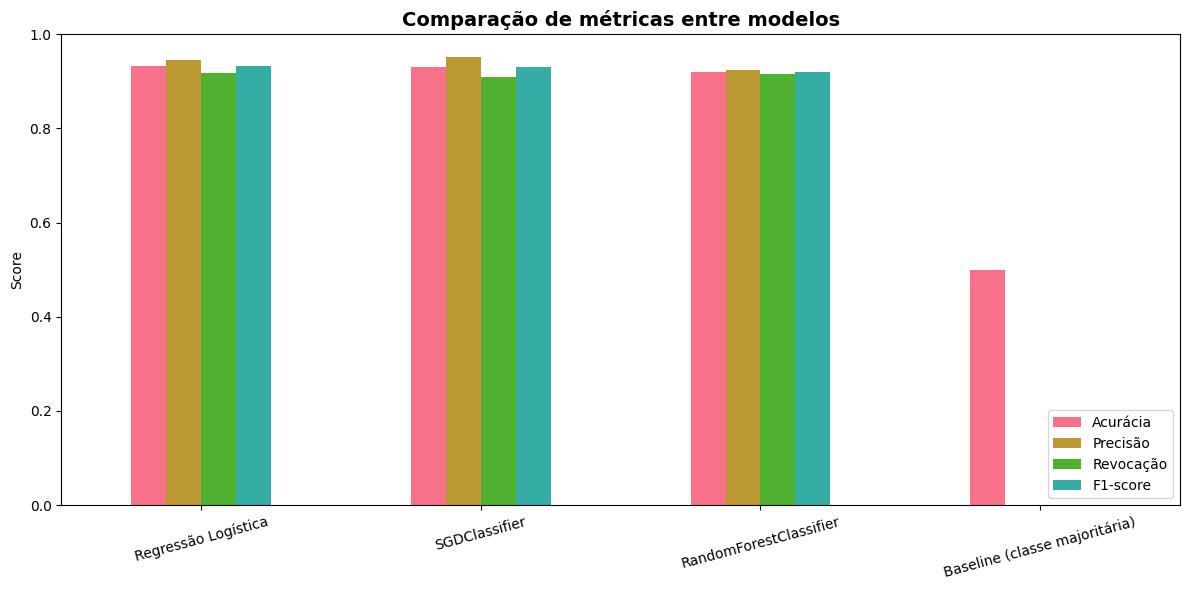

In [ ]:
comparison_df.plot(kind="bar", figsize=(12, 6))
plt.title("Comparação de métricas entre modelos", fontsize=14, fontweight="bold")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Os três modelos supervisionados apresentaram desempenho consideravelmente superior ao baseline (que, ao sempre prever a classe majoritária, obteve acurácia de apenas 50,0% e precisão/revocação nulas para a classe minoritária, evidenciando que a acurácia bruta seria enganosa sem essa referência). Entre os modelos treinados, a Regressão Logística obteve o melhor F1-score (0,9323), seguida de perto pelo SGDClassifier (0,9299, com precisão ligeiramente superior  0,9509 vs. 0,9463) e pelo RandomForestClassifier (0,9193, o modelo com desempenho mais modesto entre os três). A diferença entre os três é pequena (menos de 2 pontos percentuais de F1), o que indica que o sinal textual capturado pelo TF-IDF é forte o suficiente para que diferentes algoritmos convirjam para resultados semelhantes.

Modelo escolhido: Regressão Logística

              precision    recall  f1-score   support

    Negativo       0.92      0.95      0.93      7152
    Positivo       0.95      0.92      0.93      7150

    accuracy                           0.93     14302
   macro avg       0.93      0.93      0.93     14302
weighted avg       0.93      0.93      0.93     14302



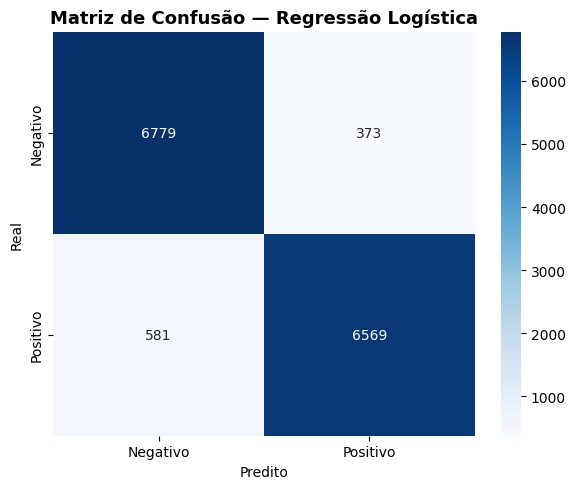

In [ ]:
best_model_name = comparison_df.index[0]
best_model = models[best_model_name]
y_pred_best = results[best_model_name]["y_pred"]

print(f"Modelo escolhido: {best_model_name}\n")
print(classification_report(y_test, y_pred_best, target_names=["Negativo", "Positivo"]))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negativo", "Positivo"], yticklabels=["Negativo", "Positivo"])
plt.title(f"Matriz de Confusão — {best_model_name}", fontsize=13, fontweight="bold")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

O modelo final escolhido foi a Regressão Logística, por apresentar o maior F1-score entre os modelos avaliados (0,93), com desempenho equilibrado entre as classes (precisão 0,92 e revocação 0,95 para negativos; precisão 0,95 e revocação 0,92 para positivos). A matriz de confusão mostra 6.779 verdadeiros negativos e 6.569 verdadeiros positivos, contra 373 falsos positivos e 581 falsos negativos, ou seja, o modelo erra um pouco mais ao classificar avaliações realmente positivas como negativas (581 casos) do que o contrário (373 casos), mas o erro geral é baixo (cerca de 6,7% do conjunto de teste).


**Discussão:**
A Regressão Logística foi o modelo com melhor resultado geral (F1-score de 0,93), superando o SGDClassifier por uma margem pequena e o RandomForestClassifier por uma margem um pouco maior — sendo inferior ao SGDClassifier apenas em precisão, e por uma diferença mínima (0,9463 vs. 0,9509). A escolha pela Regressão Logística se justifica pelo maior F1-score, que equilibra precisão e revocação, sendo uma métrica mais robusta que a acurácia isolada para avaliar classificadores.

A inspeção manual dos erros de classificação revela padrões relevantes: em vários casos, o modelo confunde avaliações que mencionam tanto aspectos positivos quanto negativos no mesmo texto (ex: elogiar o produto, mas reclamar do prazo, ou vice-versa), o que sugere dificuldade do modelo em lidar com sentimento misto — uma limitação natural de uma abordagem baseada em frequência de palavras (TF-IDF), que não captura bem negação complexa, ironia/sarcasmo ou o peso relativo de diferentes trechos de um mesmo texto.

Limitações identificadas: o modelo não captura sarcasmo nem gírias fora do vocabulário visto no treino, e tem dificuldade em avaliações com sentimento misto (elogio + crítica no mesmo texto).

Possíveis melhorias: aumentar o volume de dados de treino, testar ajuste de hiperparâmetros (ex: GridSearchCV no parâmetro C da regressão logística, ou max_features/ngram_range do TF-IDF), e explorar representações mais ricas de texto, como embeddings pré-treinados (Word2Vec, FastText ou modelos BERT em português), que capturam melhor o contexto semântico do que a contagem de palavras isolada.

In [ ]:
# Exemplo de inspeção manual de erros — ajuda a escrever a discussão acima
X_test_reset = X_test_text.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

errors_idx = np.where(y_test_reset.values != y_pred_best)[0][:5]

for i in errors_idx:
    print(f"Texto tratado: {X_test_reset.iloc[i]}")
    print(f"Real: {y_test_reset.iloc[i]} | Predito: {y_pred_best[i]}")
    print("-" * 60)

Texto tratado: quant produt entreg fiq satisfeit por fich tecn sit fal possu indic agu extern verdad possu indic intern
Real: 1.0 | Predito: 0.0
------------------------------------------------------------
Texto tratado: ....................................................................
Real: 1.0 | Predito: 0.0
------------------------------------------------------------
Texto tratado: gost produt li tod man fiz tud conform mod indic precis pass var vez cort facil apar teso
Real: 0.0 | Predito: 1.0
------------------------------------------------------------
Texto tratado: aparelh bom entant apresent defeit local chip quer sab faz poi 5 mes uso aguard respost
Real: 1.0 | Predito: 0.0
------------------------------------------------------------
Texto tratado: cheg ant praz acend tecl pod ter compr barat compr luz noturn acend
Real: 0.0 | Predito: 1.0
------------------------------------------------------------


## Exportação do modelo final

Salvamos o vetorizador e o modelo escolhido, para reutilização futura
sem necessidade de re-treinamento.

In [ ]:
import joblib

joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
joblib.dump(best_model, "modelo_final.pkl")

print(f"Modelo salvo: {best_model_name}")

Modelo salvo: Regressão Logística
